# BINARY CLASSIFICATION TASK

The purpose of this code is to train 3 types of machine learning algorithms in classifying diabetics and non-diabetics based on a set of medical variables.

Step 1. Import libraries And Data

In [12]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sn
from scipy import stats
import matplotlib.ticker as ticker
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler as MMS
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score
from sklearn.impute import KNNImputer

In [13]:
diabetes_df = pd.read_csv('diabetes.csv')
# https://www.kaggle.com/datasets/lara311/diabetes-dataset-using-many-medical-metrics/data
diabetes_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Step 2. Visualize, Analyze and Clean Data

In [14]:
# Imbalance analysis
diabetes_df.Outcome.value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

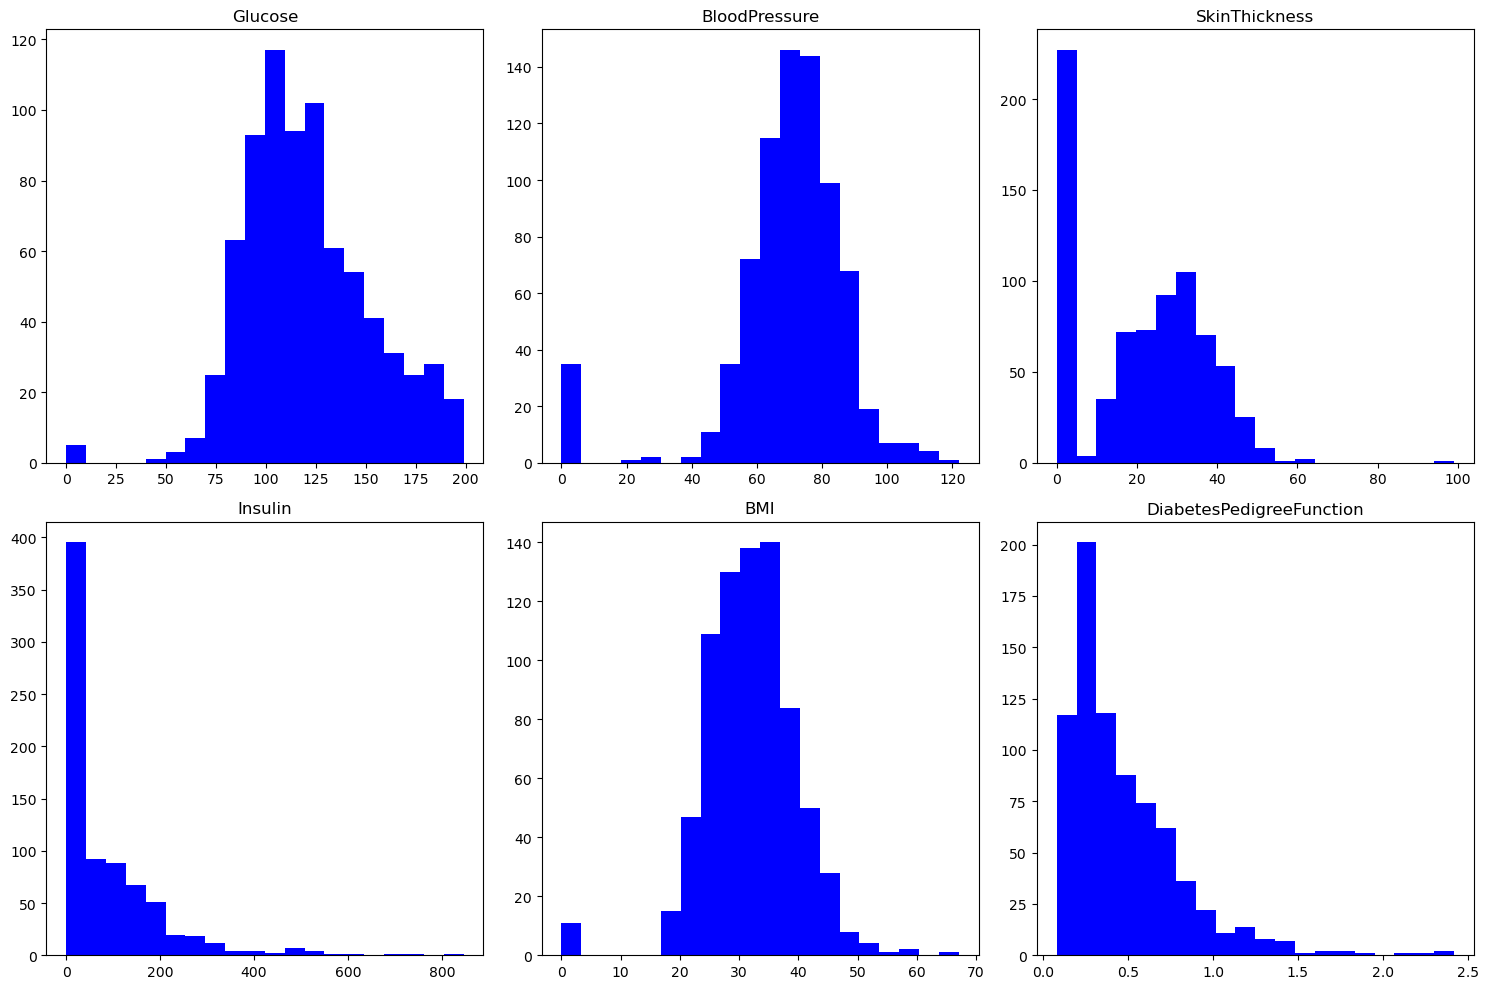

In [15]:
# Visualization of the distribution of values
def show_features_histograms(df):
    features = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction']
    
    fig, axs = plt.subplots(2, 3, figsize=(15, 10))
    axs = axs.flatten()

    for i, feature in enumerate(features):
        axs[i].hist(df[feature], bins=20, facecolor='blue')
        axs[i].set_title(feature)
    
    plt.tight_layout()
    plt.show()

show_features_histograms(diabetes_df)

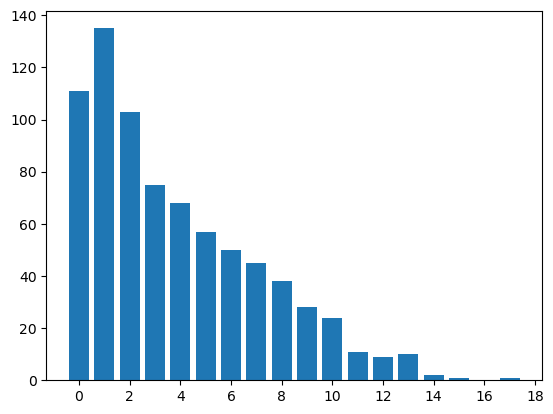

In [16]:
# Distribution of values
def show_feature_bar(df):
    fig = plt.bar(np.sort(df.Pregnancies.unique()), df.Pregnancies.value_counts().sort_index())
    plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    plt.show()

show_feature_bar(diabetes_df)

According to the graphics, we can see that some variables that should not be able to have zero values, do have zero values. These data points can be considered invalid data and should be removed

In [17]:
def zero_values_report(df):
    report = []
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            zero_count = (df[col] == 0).sum()
            if zero_count > 0:
                report.append((col, zero_count))
    return pd.DataFrame(report, columns=["Feature", "ZeroCount"]).sort_values(by="ZeroCount", ascending=False)

zero_values_report(diabetes_df)

,Feature,ZeroCount
6,Outcome,500
4,Insulin,374
3,SkinThickness,227
0,Pregnancies,111
2,BloodPressure,35
5,BMI,11
1,Glucose,5


Between the variables that contain zero values, we find the insulin varibable. Because the 0 value in the insulin variable is only possible if the person is diabetic, the zeros are either leading (and thus shouldn't be used in the ml algorithm) or could be placeholders used to indicate that these individuals weren't tested for insulin values. 
Because this information is not shared in the original dataset, a test is required. If zeros in insulin always lead to 1 (diabetic) in the outcome, they are leading, but if not, it means they are just placeholders.

In [18]:
# The insulin variable could be leading (since the value 0 must always come from a diabetic) 
# or could be a placeholder (if there are non-diabetics with a value of 0 in the insulin variable)

def zero_insuline_to_diabetes_percent(df):
    mask = df["Insulin"] == 0

    total_zero_insulin = mask.sum()
    matches = ((df["Insulin"] == 0) & (df["Outcome"] == 1)).sum()
    percentage = (matches / total_zero_insulin) * 100
    
    return print(f"{float(percentage):.2f}%")


zero_insuline_to_diabetes_percent(diabetes_df)

36.90%


Conclusion: zero values in the insulin column are placeholders.

On the next steps, other 0 values will be removed, and both missing data and duplicated data will be located and removed.

In [19]:
# Remove invalid data
conditions = (diabetes_df['Glucose'] == 0) | (diabetes_df['BMI'] == 0) | (diabetes_df['BloodPressure'] == 0) | (diabetes_df['SkinThickness'] == 0)
valid_df = diabetes_df[~conditions].copy()

# Converting placehlder from 0 to NaN
valid_df['Insulin'] = valid_df['Insulin'].replace(0, np.nan)

valid_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,NaN,33.6,0.627,50,1
1,1,85,66,29,NaN,26.6,0.351,31,0
3,1,89,66,23,94.0,28.1,0.167,21,0
4,0,137,40,35,168.0,43.1,2.288,33,1
6,3,78,50,32,88.0,31.0,0.248,26,1


In [20]:
valid_df.Outcome.value_counts()

Outcome
0    355
1    177
Name: count, dtype: int64

In [21]:
# Find missing values
findings = list()
for feature in diabetes_df.columns:
    findings.append(f'Total missing values for {feature}: {diabetes_df[feature].isna().sum()}')
print()

# Find duplicated data
findings.append(f'Total duplicated observations: {diabetes_df.duplicated().sum()}')

findings

['Total missing values for Pregnancies: 0',
 'Total missing values for Glucose: 0',
 'Total missing values for BloodPressure: 0',
 'Total missing values for SkinThickness: 0',
 'Total missing values for Insulin: 0',
 'Total missing values for BMI: 0',
 'Total missing values for DiabetesPedigreeFunction: 0',
 'Total missing values for Age: 0',
 'Total missing values for Outcome: 0',
 'Total duplicated observations: 0']

In [22]:
# Use knn to fill the NaN values for insulin. This is a temporary EDA transformation that wont be used later for the actual training of the models
imputer = KNNImputer(n_neighbors=5) 
eda_X = valid_df.drop("Outcome", axis=1) 
eda_y = valid_df["Outcome"] 
eda_X_filled = imputer.fit_transform(eda_X)

eda_X_filled = pd.DataFrame(eda_X_filled, columns=eda_X.columns)
eda_df = pd.concat([eda_X_filled, eda_y.reset_index(drop=True)], axis=1)

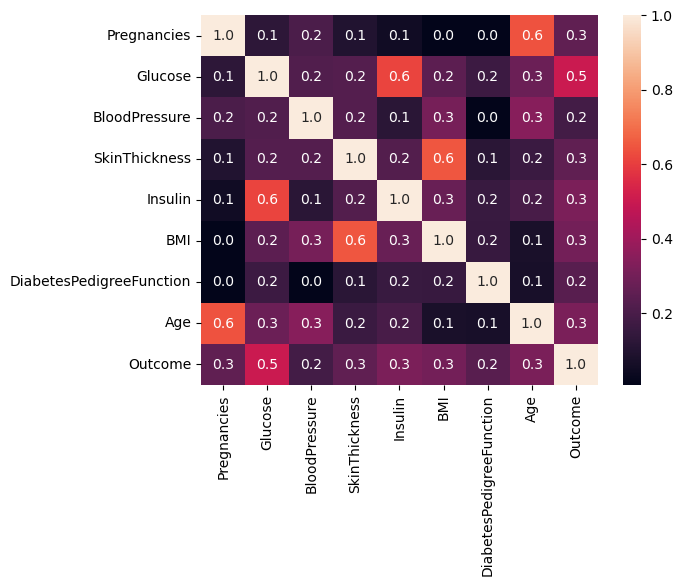

In [23]:
# Visualize correlations
def show_heatmap(df):
    sn.heatmap(data = df.corr(), annot = True, fmt='.1f')
    plt.show()

show_heatmap(eda_df)

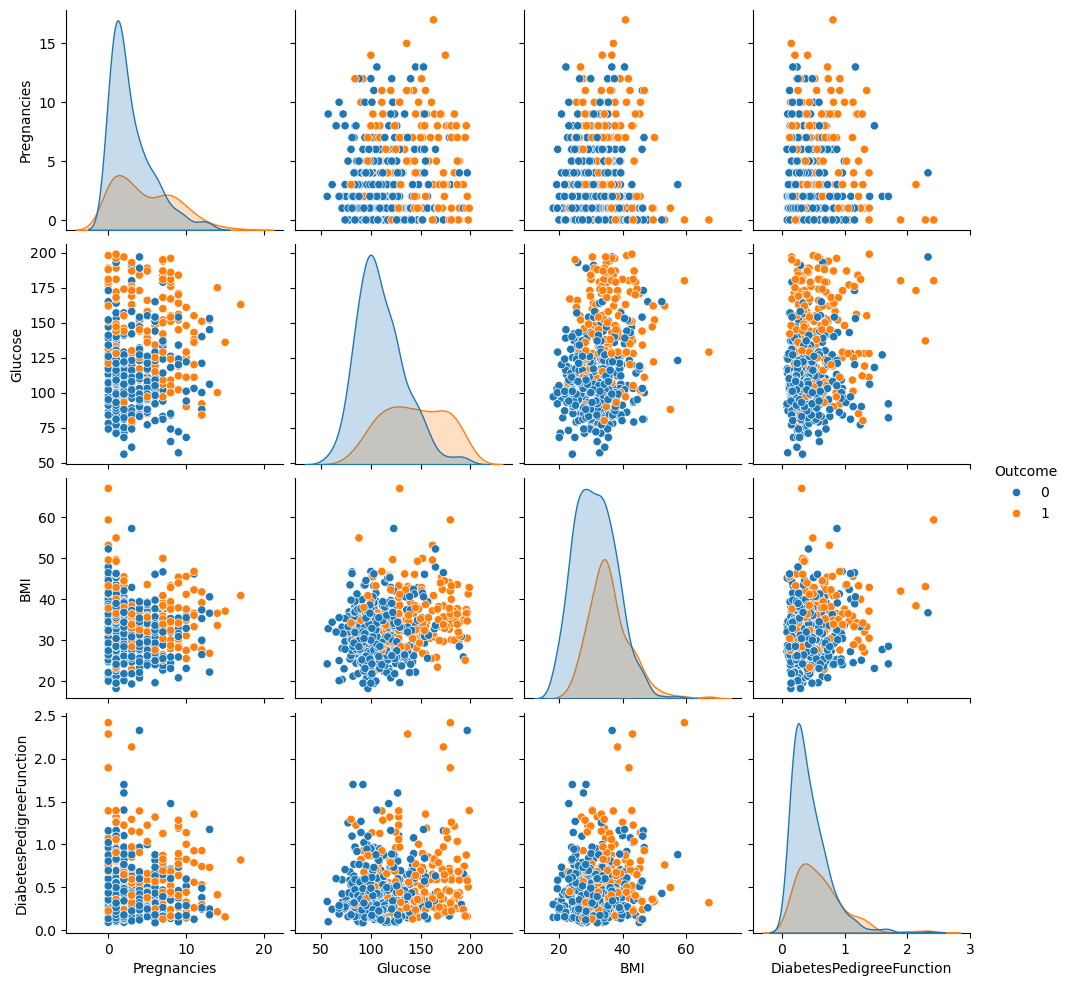

In [24]:
# Visualization of the relationship between pairs of variables
def show_pairplot(df):
    sn.pairplot(df, hue ='Outcome', vars = ['Pregnancies', 'Glucose', 'BMI', 'DiabetesPedigreeFunction'])
    plt.show()

show_pairplot(eda_df)

Step 3. Split and Transform Data

In [25]:
# Split Data
X = valid_df.loc[:, valid_df.columns != 'Outcome']
y = valid_df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Use knn to fill the NaN values for insulin. This version is the one to be used for the training of the models
imputer = KNNImputer(n_neighbors=5) 
X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

In [26]:
# Delete outliers with IQR method

features = ['Glucose', 'BMI', 'DiabetesPedigreeFunction', 'BloodPressure', 'SkinThickness']

mask = pd.Series(True, index=X_train.index)

for feature in features:

    # Calculate Q1 (25th percentile) and Q3 (75th percentile)
    Q1 = X_train[feature].quantile(0.25)
    Q3 = X_train[feature].quantile(0.75)

    # Calculate IQR
    IQR = Q3 - Q1

    # Define the bounds for outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # mask for outlier filtering
    mask &= X_train[feature].between(lower_bound, upper_bound)

# Apply mask
X_train = X_train[mask]
y_train = y_train[mask]

In [27]:
# Analize if the data follows a normal distribution (relevant for linear SVC and logistic regression)
features = ['Pregnancies','Glucose', 'BMI', 'Insulin', 'Age', 'DiabetesPedigreeFunction', 'BloodPressure', 'SkinThickness']
for feature in features:
    print(f'{feature} kurtosis: {round(stats.kurtosis(X_train[feature]),4)}')
    print(f'{feature} skew: {round(stats.skew(X_train[feature]),3)}')
    print()

Pregnancies kurtosis: 0.6066
Pregnancies skew: 1.121

Glucose kurtosis: -0.3901
Glucose skew: 0.57

BMI kurtosis: -0.2869
BMI skew: 0.255

Insulin kurtosis: 3.4917
Insulin skew: 1.75

Age kurtosis: 1.5377
Age skew: 1.379

DiabetesPedigreeFunction kurtosis: 0.1374
DiabetesPedigreeFunction skew: 0.883

BloodPressure kurtosis: -0.4445
BloodPressure skew: -0.02

SkinThickness kurtosis: -0.5337
SkinThickness skew: 0.147



To be considered normal distribution the acceptable skewness is -0.75 and +075, ideally between -0.5 and +0.5. Kurtosis should be between -2 and 2.

Variables that follow a normal distribution: glucose, BMI, blood pressure, skin thickness

Variables that don't follow  a normal distribution: pregnancies, insulin, age, diabete pedigree function

We will reduce skewness by applying a logaritmic transformation (log1p allows for features with values equal to 0, but can't handle negative data, luckily of the features to be transformed has negatives values) and later standardize the data.

In [28]:
def data_transformer_log1p(data_frame):
    features = ["Pregnancies", "Insulin", "Age", "DiabetesPedigreeFunction"]
    data_frame[features] = data_frame[features].apply(lambda x: np.log1p(x))
    return data_frame

X_train = data_transformer_log1p(X_train)

# Re-analize if the data follows a normal distribution
features = ['Pregnancies', 'Insulin', 'Age', 'DiabetesPedigreeFunction']
for feature in features:
    print(f'{feature} kurtosis: {round(stats.kurtosis(X_train[feature]),4)}')
    print(f'{feature} skew: {round(stats.skew(X_train[feature]),3)}')
    print()

Pregnancies kurtosis: -0.9038
Pregnancies skew: -0.064

Insulin kurtosis: 0.049
Insulin skew: -0.051

Age kurtosis: -0.253
Age skew: 0.846

DiabetesPedigreeFunction kurtosis: -0.5063
DiabetesPedigreeFunction skew: 0.55



All features now follow a normal distribution.

In [29]:
def create_MMS_scaler(train_data_frame):
    scaler = MMS().fit(X_train)
    return scaler

def apply_MMS_scaler(data_frame, scaler):
    return scaler.transform(data_frame)

MMS_scaler = create_MMS_scaler(X_train)
X_train_scaled = apply_MMS_scaler(X_train, MMS_scaler)

X_train_scaled

array([[0.79248125, 0.84507042, 0.79310345, ..., 0.48742138, 0.40334506,
        0.7498004 ],
       [0.25      , 0.11971831, 0.10344828, ..., 0.1509434 , 0.18715418,
        0.        ],
       [0.75      , 0.35211268, 0.82758621, ..., 0.14150943, 0.17315221,
        0.60864328],
       ...,
       [0.5       , 0.19014085, 0.24137931, ..., 0.50628931, 0.27826641,
        0.12697198],
       [0.        , 0.33802817, 0.34482759, ..., 0.48427673, 0.44197627,
        0.03378623],
       [0.58048202, 0.69014085, 0.31034483, ..., 0.4591195 , 0.17531593,
        0.06613431]], shape=(401, 8))

Step 4. Train and Compare Models

In [30]:
# Apply transformations to test data
X_test = data_transformer_log1p(X_test)
X_test_scaled = apply_MMS_scaler(X_test, MMS_scaler)

In [31]:
def test_accuracy_recall(best_model, X80, X20, y80, y20, threshold=None):
    # Test accuracy and recall for train and test (to look for best model and assure no overfitting is happening)

    if threshold is None:
        y20_predicted = best_model.predict(X20)
        y80_predicted = best_model.predict(X80)
    else:
        y20_proba = best_model.predict_proba(X20)[:, 1]
        y80_proba = best_model.predict_proba(X80)[:, 1]

        y20_predicted = (y20_proba >= threshold).astype(int)
        y80_predicted = (y80_proba >= threshold).astype(int)

    train_accuracy = round(accuracy_score(y80, y80_predicted),3)
    test_accuracy = round(accuracy_score(y20, y20_predicted),3)
    train_recall = round(recall_score(y80, y80_predicted),3)
    test_recall = round(recall_score(y20, y20_predicted),3)

    return (f'train accuracy = {train_accuracy}, test accuracy = {test_accuracy}, train recall = {train_recall}, test recall = {test_recall}')

def train_lr(X80, X20, y80, y20):
    clf = LogisticRegression() 
 
    # Find best parameters for the model
    grid_values = {'C': [0.1, 0.5, 1.0, 10]}
    grid_clf = GridSearchCV(clf, param_grid = grid_values, scoring='recall')
    grid_clf.fit(X80, y80)
    best_model = grid_clf.best_estimator_

    return test_accuracy_recall(best_model, X80, X20, y80, y20, threshold=0.35)

def train_svm(X80, X20, y80, y20):
    clf = LinearSVC()
    
    # Find best parameters for the model
    grid_values = {'C': [0.1, 0.5, 1.0, 10]}
    grid_clf = GridSearchCV(clf, param_grid = grid_values, scoring='recall')
    grid_clf.fit(X80, y80)
    best_model = grid_clf.best_estimator_

    return test_accuracy_recall(best_model, X80, X20, y80, y20)

def train_rf(X80, X20, y80, y20):
    clf = RandomForestClassifier(random_state=42)

    # Find best parameters for the model
    grid_values = {'n_estimators': [25, 50, 75, 100], 'max_features': [1, 2, 3], 'max_depth' : [2, 3]}
    grid_clf = GridSearchCV(clf, param_grid = grid_values, scoring='recall')
    grid_clf.fit(X80, y80)
    best_model = grid_clf.best_estimator_

    return test_accuracy_recall(best_model, X80, X20, y80, y20, threshold=0.35)

def train_models(X80, X20, y80, y20):
    results = dict()
    results['Logistic_Regression'] = train_lr(X80, X20, y80, y20)
    results['Support Vector Machine'] = train_svm(X80, X20, y80, y20)
    results['Random Forest'] = train_rf(X80, X20, y80, y20)
    return results

# Train different models and return their accuracy to compare their performance
model_scores = train_models(X_train_scaled, X_test_scaled, y_train, y_test)
model_scores

{'Logistic_Regression': 'train accuracy = 0.778, test accuracy = 0.766, train recall = 0.736, test recall = 0.722',
 'Support Vector Machine': 'train accuracy = 0.781, test accuracy = 0.794, train recall = 0.55, test recall = 0.611',
 'Random Forest': 'train accuracy = 0.825, test accuracy = 0.776, train recall = 0.822, test recall = 0.861'}

Since the goal is to aggressively identify diabetic patients and minimize false negatives, recall was considered the most important evaluation metric. Among the trained models, the Random Forest classifier achieved the best performance, with a test recall score of 0.861.